# P0 · Text, positions, and slices

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys
print("Python", sys.version.split()[0])
print("Self-contained notebook. Run top to bottom; no repository clone or API key.")


Python 3.12.3
Self-contained notebook. Run top to bottom; no repository clone or API key.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P0.2 · Text, positions, and slices

A slice includes its start and excludes its stop. Text positions and encoded byte positions are different units.

**Prerequisites:** Read, run, inspect

**Predict:** What does "abcdef"[1:4] return?

**Mental model:** A transformer receives a limited context window. Before creating tensors, you need to say exactly which text positions belong to that window.

### Why this operation exists

A transformer receives a limited context window. Before creating tensors, you need to say exactly which text positions belong to that window.

Python starts counting at zero. A slice uses a starting boundary and an ending boundary, so three positions lie between boundaries zero and three.

Move both boundaries one place to obtain the next window. Move the target window one place ahead to describe the next-character prediction task.

Whitespace is data. A space or newline may be visually quiet while still occupying a position and needing its own character ID.

Keep the unit of counting explicit. A Python string, a U T F eight byte sequence and a tokenizer's tokens can have different lengths.

### Follow the values

Lay out the six positions of the example, with a visible space tile and a visible newline tile.

The first three-position slice selects t, o and the space. The ending boundary does not select the character b at position three.

Shift the same window one place forward. The targets become o, the space and b: one next character for every input position.

A negative index counts back from the end. Index minus one selects the newline, whose representation makes the escape visible.

The accented letter has one Python string position here and two U T F eight bytes, 195 and 169. Decoding those bytes reconstructs the original text.

In [3]:
FRAMES.clear()
change = 0
text = "to be\n"
show("Characters, including whitespace", list(text))
start = 1 if change else 0
show("Window text[start:start+3]", list(text[start:start+3]))
show("Shifted next characters", list(text[start+1:start+4]))
show("Last character, shown explicitly", repr(text[-1]))
show("Text versus UTF-8 bytes", {"text": "é", "text positions": len("é"), "bytes": list("é".encode("utf-8"))})

Characters, including whitespace: ["t", "o", " ", "b", "e", "\n"]
Window text[start:start+3]: ["t", "o", " "]
Shifted next characters: ["o", " ", "b"]
Last character, shown explicitly: "'\\n'"
Text versus UTF-8 bytes: {"text": "é", "text positions": 1, "bytes": [195, 169]}


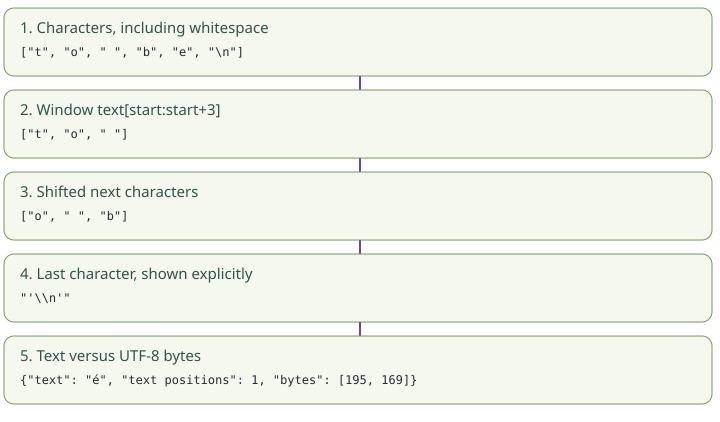

In [4]:
draw_trace()

### Read the implementation

Use list of text to expose its positions. The notebook helper renders whitespace explicitly so a blank tile cannot be mistaken for missing data.

The start variable is the experiment control. Both window boundaries move together, preserving the requested window length when enough text remains.

The target expression adds one to both boundaries. Check equal input and target lengths before using a pair for training.

Indexing returns one element; slicing returns a sequence. An oversized slice stops at the available boundary, while an out-of-range single index raises an error.

Encode with U T F eight to inspect bytes and decode with the same encoding to recover text. Later tokenization adds a separate mapping from text pieces to token IDs.

### Change one thing

**Move the window start from 0 to 1**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [5]:
FRAMES.clear()
change = 1
text = "to be\n"
show("Characters, including whitespace", list(text))
start = 1 if change else 0
show("Window text[start:start+3]", list(text[start:start+3]))
show("Shifted next characters", list(text[start+1:start+4]))
show("Last character, shown explicitly", repr(text[-1]))
show("Text versus UTF-8 bytes", {"text": "é", "text positions": len("é"), "bytes": list("é".encode("utf-8"))})

Characters, including whitespace: ["t", "o", " ", "b", "e", "\n"]
Window text[start:start+3]: ["o", " ", "b"]
Shifted next characters: [" ", "b", "e"]
Last character, shown explicitly: "'\\n'"
Text versus UTF-8 bytes: {"text": "é", "text positions": 1, "bytes": [195, 169]}


### A useful distinction

String length counts Unicode code points, not necessarily displayed graphemes, bytes, or model tokens.

In [6]:
assert "é".encode("utf-8").decode("utf-8") == "é"
assert len("e\u0301") == 2  # one displayed accented letter, two code points
assert "abc"[10:20] == ""
try:
    "abc"[10]
except IndexError:
    print("An index failed; a slice would have been empty.")

An index failed; a slice would have been empty.


### ✋ Your turn

For text="abcdef", return the two strings for a length-3 input window starting at 1 and its shifted targets.

In [7]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == ("bcd", "cde"), 'String length counts Unicode code points, not necessarily displayed graphemes, bytes, or model tokens.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [8]:
#@title Show a solution { display-mode: "form" }
text = "abcdef"
answer = (text[1:4], text[2:5])

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == ("bcd", "cde"), 'String length counts Unicode code points, not necessarily displayed graphemes, bytes, or model tokens.'
    print("✓ right:", answer)

✓ right: ('bcd', 'cde')


### Reconnect to the transformer

The current character model constructs input and target slices from one encoded stream. Their one-position offset is the supervision signal.

During generation, a negative slice keeps only the most recent context that fits the model. Cropping a context changes which positions are available.

The character model and Phyll use different tokenizers. A U T F eight byte is not automatically one Phyll token, and a token is not necessarily one displayed character.

Tokenization details belong in the later tokenizer lesson. Here the transferable skill is tracking the representation and the boundaries you are slicing.

Next, examine the containers that hold those positions, and the difference between changing a container and copying it.

```python
x = data[start:start + context]
y = data[start + 1:start + context + 1]
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** What does "abcdef"[1:4] return?

<details><summary>Check your explanation</summary>

bcd. String length counts Unicode code points, not necessarily displayed graphemes, bytes, or model tokens.

</details>